# Current Signature Dataset - Advanced ML Training

This notebook implements a robust Machine Learning pipeline for the **Mendeley Current Signature Dataset**.

## Objectives
1.  **Full Data Utilization**: Verify and process all available files.
2.  **Class Balancing**: Use **SMOTE** to handle imbalanced classes.
3.  **Advanced Visualization**: ROC Curves, Learning Curves, Correlation Heatmaps, and Model Comparisons.
4.  **Model Comparison**: Evaluate Random Forest, SVM, and KNN.

## 1. Setup & Imports

In [16]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data.current_signature_loader import CurrentSignatureLoader

print("Imports successful!")

Imports successful!


## 2. Load Data & Verify Completeness

Loading Data... This may take a moment.
Found 8 folders in ../Current Signature Data/Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions
Processing folder: 3-Phase-current-0.7mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-0.9mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.1mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.3mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.5mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-1.7mm-bearing-fault -> Label: bearing_fault
Processing folder: 3-Phase-current-12-4mm-broken-rotor-bar-fault -> Label: broken_rotor_bar
Processing folder: 3-Phase-current-healthy-motor -> Label: healthy

--- Data Verification ---
Total Samples (Windows): 5170
Feature Count: 27


C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_19264\2985643914.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette='viridis')


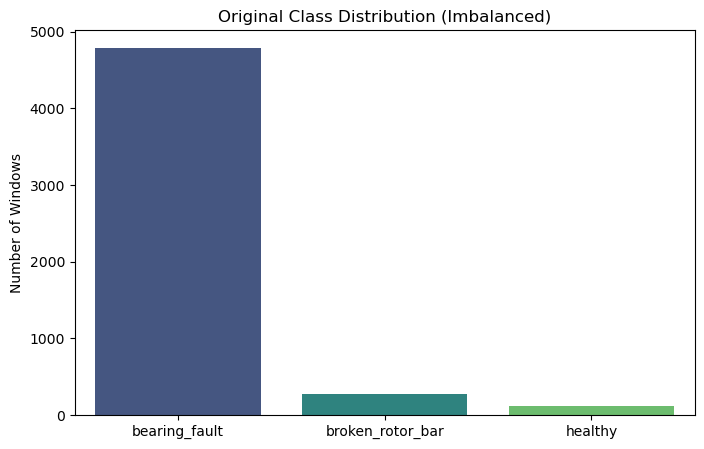

Class Counts: {np.str_('bearing_fault'): np.int64(4782), np.str_('broken_rotor_bar'): np.int64(272), np.str_('healthy'): np.int64(116)}


In [17]:
DATA_DIR = r'../Current Signature Data/Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions'

loader = CurrentSignatureLoader(DATA_DIR)
print("Loading Data... This may take a moment.")
X, y = loader.load_data()

print(f"\n--- Data Verification ---")
print(f"Total Samples (Windows): {X.shape[0]}")
print(f"Feature Count: {X.shape[1]}")

# Check Class Distribution BEFORE SMOTE
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 5))
sns.barplot(x=unique, y=counts, palette='viridis')
plt.title("Original Class Distribution (Imbalanced)")
plt.ylabel("Number of Windows")
plt.show()

print("Class Counts:", dict(zip(unique, counts)))

## 3. Preprocessing & Class Balancing (SMOTE)

Classes: ['bearing_fault' 'broken_rotor_bar' 'healthy']

Applying SMOTE to balance classes...
Original Train Shape: (4136, 27)
Resampled Train Shape: (11475, 27)


C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_19264\1100711182.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names[unique_res], y=counts_res, palette='viridis')


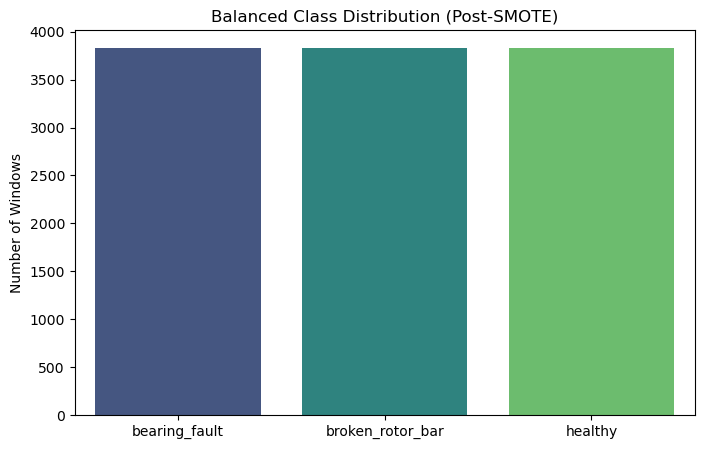

Resampled Class Counts: {np.str_('bearing_fault'): np.int64(3825), np.str_('broken_rotor_bar'): np.int64(3825), np.str_('healthy'): np.int64(3825)}


In [18]:
# 1. Handle NaNs/Infs
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# 2. Encode Labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
print(f"Classes: {class_names}")

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# 4. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Apply SMOTE (Synthetic Minority Over-sampling Technique)
print("\nApplying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Train Shape: {X_train_scaled.shape}")
print(f"Resampled Train Shape: {X_train_resampled.shape}")

# Check Class Distribution AFTER SMOTE
unique_res, counts_res = np.unique(y_train_resampled, return_counts=True)
plt.figure(figsize=(8, 5))
sns.barplot(x=class_names[unique_res], y=counts_res, palette='viridis')
plt.title("Balanced Class Distribution (Post-SMOTE)")
plt.ylabel("Number of Windows")
plt.show()

print("Resampled Class Counts:", dict(zip(class_names[unique_res], counts_res)))

## 4. Feature Correlation Analysis

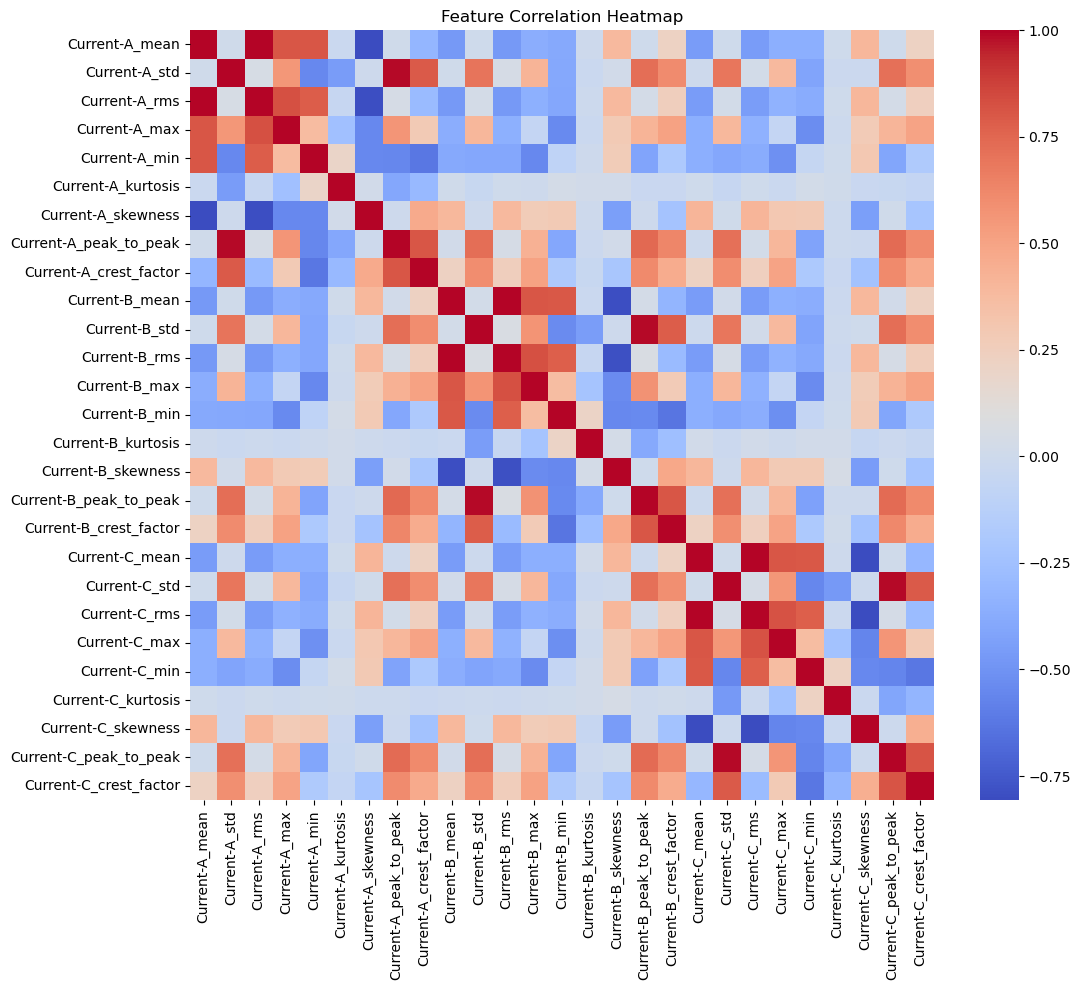

In [19]:
# Plot Correlation Heatmap of Features
plt.figure(figsize=(12, 10))
corr_matrix = pd.DataFrame(X_train_scaled, columns=X.columns).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Model Training & Evaluation

In [20]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'Training Time (s)': []
}

trained_models = {}
confusion_matrices = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    start_time = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    end_time = time.time()
    
    train_time = end_time - start_time
    trained_models[name] = model
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['Precision'].append(prec)
    results['Recall'].append(rec)
    results['F1-Score'].append(f1)
    results['Training Time (s)'].append(train_time)
    
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Store Confusion Matrix
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)


--- Training Random Forest ---
Accuracy: 0.9275
                  precision    recall  f1-score   support

   bearing_fault       0.96      0.96      0.96       957
broken_rotor_bar       0.32      0.35      0.34        54
         healthy       1.00      1.00      1.00        23

        accuracy                           0.93      1034
       macro avg       0.76      0.77      0.77      1034
    weighted avg       0.93      0.93      0.93      1034


--- Training SVM ---
Accuracy: 0.7524
                  precision    recall  f1-score   support

   bearing_fault       0.97      0.75      0.85       957
broken_rotor_bar       0.13      0.67      0.22        54
         healthy       1.00      0.96      0.98        23

        accuracy                           0.75      1034
       macro avg       0.70      0.79      0.68      1034
    weighted avg       0.93      0.75      0.82      1034


--- Training KNN ---
Accuracy: 0.8104
                  precision    recall  f1-score   suppo

## 6. Advanced Visualizations


--- Model Performance Summary ---
           Model  Accuracy  Precision    Recall  F1-Score  Training Time (s)
0  Random Forest  0.927466   0.930567  0.927466  0.928976           7.371184
1            SVM  0.752418   0.930867  0.752418  0.819077          18.967605
2            KNN  0.810445   0.930625  0.810445  0.857766           0.001320


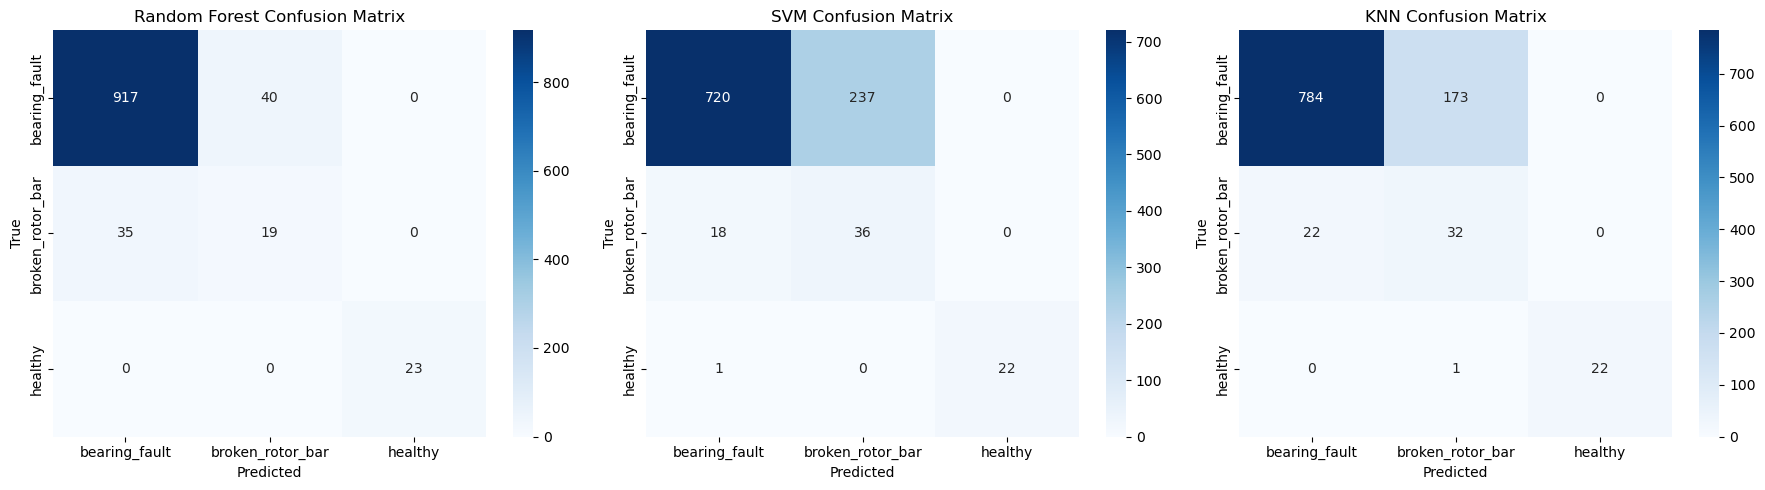

C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_19264\22580392.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


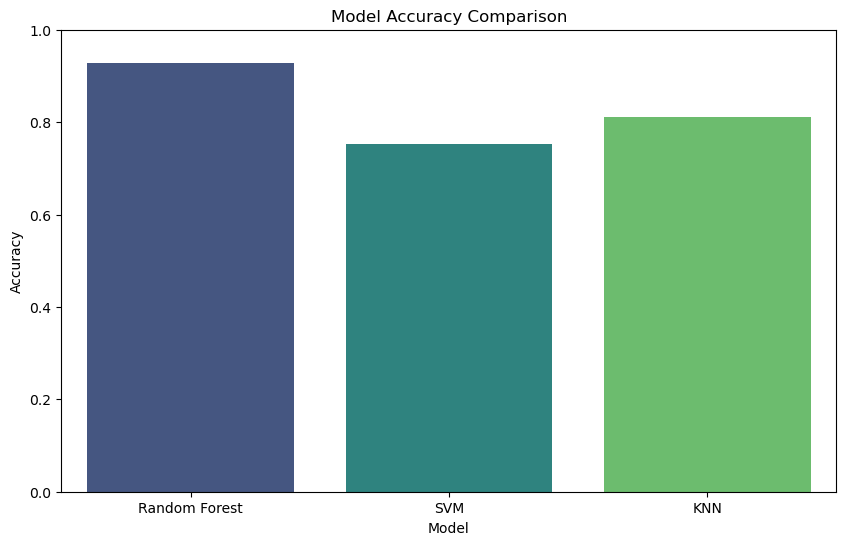


--- Plotting ROC Curves ---


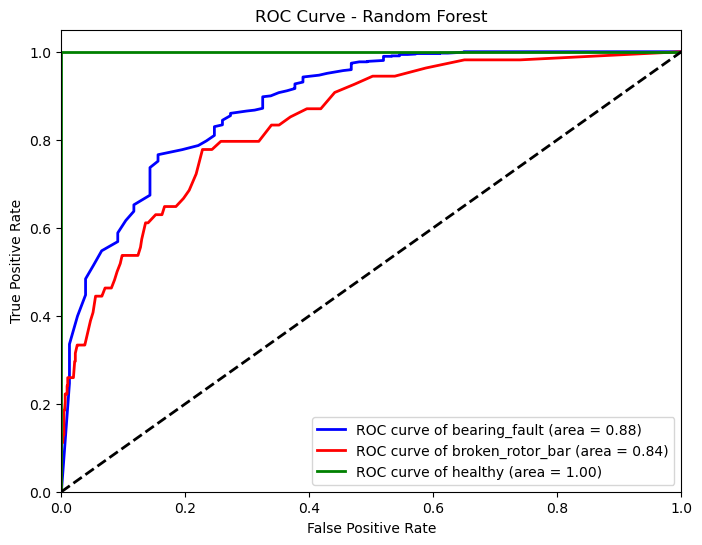

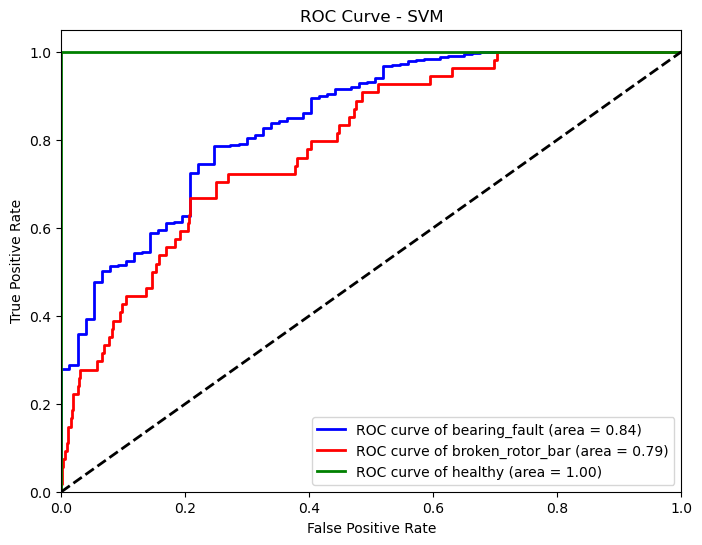

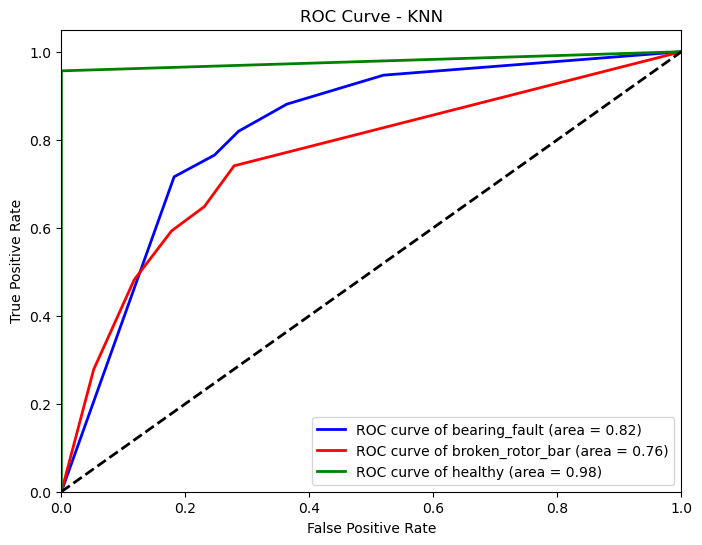


--- Plotting Learning Curves (Random Forest) ---


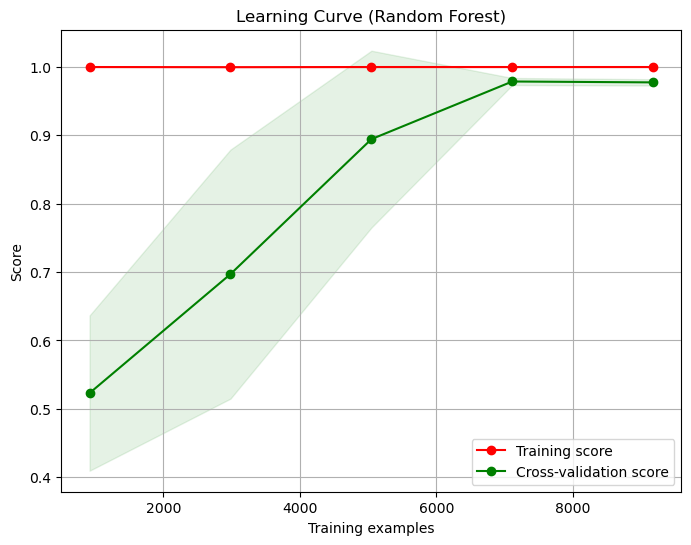

In [21]:
# --- 1. Performance Summary Table ---
results_df = pd.DataFrame(results)
print("\n--- Model Performance Summary ---")
print(results_df)

# --- 2. Side-by-Side Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[i])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.tight_layout()
plt.show()

# --- 3. Model Comparison Bar Chart ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.ylim(0, 1.0)
plt.title("Model Accuracy Comparison")
plt.show()

# --- 4. ROC Curves ---
def plot_multiclass_roc(model, X_test, y_test, n_classes, class_names, model_name):
    y_score = model.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))
                 
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

print("\n--- Plotting ROC Curves ---")
for name, model in trained_models.items():
    plot_multiclass_roc(model, X_test_scaled, y_test, len(class_names), class_names, name)

# --- 5. Learning Curves ---
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

print("\n--- Plotting Learning Curves (Random Forest) ---")
plot_learning_curve(trained_models['Random Forest'], "Learning Curve (Random Forest)", 
                    X_train_resampled, y_train_resampled, cv=5)

In [22]:
# Save Best Model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
print(f"\nBest Model: {best_model_name}")

save_dir = r'../Trained_models/current_signature_ml'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(trained_models[best_model_name], os.path.join(save_dir, 'best_ml_model.pkl'))
joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(le, os.path.join(save_dir, 'label_encoder.pkl'))

print(f"Saved best model to {save_dir}")


Best Model: Random Forest
Saved best model to ../Trained_models/current_signature_ml
